## Purpose
We've now solved for model parameters directly, with linear regression's closed-form OLS solution, and iteratively, with gradient descent. Both problems boiled down to finding where a derivative equals zero. The more general version of that problem — finding where some function $f$ itself equals zero, with no derivative in sight — shows up everywhere: pricing a bond to match a target yield, finding the break-even point of a nonlinear cost curve, or solving an equilibrium condition that has no closed form. This is root-finding. In this article we'll build three classic iterative root-finders from scratch — Newton's method, Halley's method, and the secant method — and compare how fast, and how reliably, each one converges.

## What is Root-Finding
Root-finding is the problem of locating a value $x$ such that $f(x) = 0$, for some function $f$ that usually doesn't hand us a formula for the answer directly.

- **Newton's method** stands on the curve at your current guess, looks at the slope beneath its feet, and follows that tangent line down to where it crosses zero. That crossing point becomes the next guess. It's fast, provided you're reasonably close to a root and you know (or can compute) the derivative.
- **Halley's method** does the same thing, but also takes the curve's *curvature* into account, fitting a bending line rather than a straight one. That extra piece of information usually means fewer steps to converge, at the cost of needing the second derivative too.
- **The secant method** is for when the derivative isn't available, or is too expensive to compute. Instead of a tangent line, it draws a straight line — a *secant* line — through the last two points you've already evaluated, and uses where that line crosses zero as the next guess. It converges a bit slower than Newton's method per step, but needs nothing more than the function itself.

All three are *local* methods: they only look at the neighborhood of the current guess, so where you start matters. A good starting point converges quickly; a bad one can converge to the wrong root, or not converge at all.

## Math behind Root-Finding

### Newton's Method
Suppose we're at a guess $x_n$ that isn't quite a root. We can approximate $f$ near $x_n$ with its tangent line (a first-order Taylor expansion):

$$f(x) \approx f(x_n) + f'(x_n)(x - x_n)$$

Newton's method takes the *root of that tangent line* as the next guess: setting the right-hand side to zero and solving for $x$ gives

$$x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$$

Near a simple root, the error roughly squares each step, $e_{n+1} \approx C e_n^2$ — this is called quadratic convergence, and it's why Newton's method is the workhorse of root-finding whenever a derivative is available.

### Halley's Method
Halley's method (named for Edmond Halley, of comet fame) goes one order further, using the second-order Taylor expansion:

$$f(x) \approx f(x_n) + f'(x_n)(x - x_n) + \frac{1}{2} f''(x_n)(x - x_n)^2$$

Solving this quadratic directly for its root is possible, but awkward — it involves a square root and a choice of which of the two solutions to keep. Halley's method sidesteps that by instead approximating $f$ with a rational function that matches the same first and second derivatives, which has a single, well-behaved root. That gives the update rule:

$$x_{n+1} = x_n - \frac{2 f(x_n) f'(x_n)}{2 f'(x_n)^2 - f(x_n) f''(x_n)}$$

This converges cubically, $e_{n+1} \approx C e_n^3$, roughly tripling the number of correct digits each step instead of doubling them, at the cost of a second derivative evaluation every iteration.

### Secant Method
What if $f'$ isn't available? We can approximate it using the last two guesses, $x_{n-1}$ and $x_n$, as a finite difference:

$$f'(x_n) \approx \frac{f(x_n) - f(x_{n-1})}{x_n - x_{n-1}}$$

Substituting this into Newton's update rule in place of $f'(x_n)$ gives the secant method:

$$x_{n+1} = x_n - f(x_n) \, \frac{x_n - x_{n-1}}{f(x_n) - f(x_{n-1})}$$

Unlike Newton's or Halley's method, this needs two starting points instead of one. Its error obeys $e_{n+1} \approx C \, e_n \, e_{n-1}$ — each new error scales with the *product* of the two previous errors, rather than the square of just the last one. Assuming $e_{n+1} \sim e_n^{p}$ and substituting gives $p^2 = p + 1$, whose positive root is the golden ratio, $p = \varphi \approx 1.618$. So the secant method converges superlinearly — faster than a straight line, but slower than Newton's quadratic rate — without ever touching a derivative.

## Example
We'll first implement all three methods on a simple scalar function, so we can sanity-check them against a known answer, then extend the same update rules to the complex plane to visualize how each method carves up its starting points into basins of attraction — one basin per root.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

As a sanity check, we'll find $\sqrt 2$ by solving $f(x) = x^2 - 2 = 0$, since we already know the answer. Below is a `RootFinder` class with a method for each of the three update rules, mirroring the math as closely as possible.

In [2]:
class RootFinder:
    def __init__(self, f, fprime=None, fprime2=None, tol=1e-12, max_iter=100):
        self.f = f
        self.fprime = fprime
        self.fprime2 = fprime2
        self.tol = tol
        self.max_iter = max_iter

    def newton(self, x0):
        x = x0
        history = [x]
        for _ in range(self.max_iter):
            if abs(self.f(x)) < self.tol:
                break
            x = x - self.f(x) / self.fprime(x)
            history.append(x)
        return x, history

    def halley(self, x0):
        x = x0
        history = [x]
        for _ in range(self.max_iter):
            fx = self.f(x)
            if abs(fx) < self.tol:
                break
            fpx, fppx = self.fprime(x), self.fprime2(x)
            x = x - (2 * fx * fpx) / (2 * fpx ** 2 - fx * fppx)
            history.append(x)
        return x, history

    def secant(self, x0, x1):
        history = [x0, x1]
        for _ in range(self.max_iter):
            fx0, fx1 = self.f(x0), self.f(x1)
            if abs(fx1) < self.tol:
                break
            x0, x1 = x1, x1 - fx1 * (x1 - x0) / (fx1 - fx0)
            history.append(x1)
        return x1, history

In [3]:
f = lambda x: x ** 2 - 2
fprime = lambda x: 2 * x
fprime2 = lambda x: 2.0
true_root = np.sqrt(2)

rf = RootFinder(f, fprime, fprime2)
root_n, hist_n = rf.newton(1.0)
root_h, hist_h = rf.halley(1.0)
root_s, hist_s = rf.secant(1.0, 2.0)

for name, root, hist in [("Newton", root_n, hist_n), ("Halley", root_h, hist_h), ("Secant", root_s, hist_s)]:
    print(f"{name:>7}: root = {root:.12f}, iterations = {len(hist) - 1}")

 Newton: root = 1.414213562373, iterations = 5
 Halley: root = 1.414213562373, iterations = 3
 Secant: root = 1.414213562373, iterations = 7


All three land on $\sqrt 2 \approx 1.41421356$, as expected, but in noticeably different numbers of iterations. Let's plot the error at each iteration on a log scale to see the convergence rates directly.

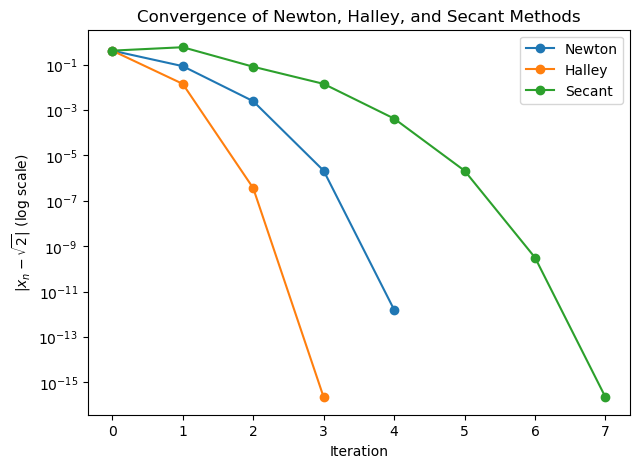

In [4]:
plt.figure(figsize=(7, 5))
for name, hist in [("Newton", hist_n), ("Halley", hist_h), ("Secant", hist_s)]:
    errors = np.abs(np.array(hist) - true_root)
    errors = np.where(errors == 0, np.nan, errors)
    plt.semilogy(errors, marker="o", label=name)
plt.xlabel("Iteration")
plt.ylabel("$|x_n - \sqrt{2}|$ (log scale)")
plt.title("Convergence of Newton, Halley, and Secant Methods")
plt.legend()

The steeper the downward slope on a log scale, the faster the convergence. Halley's method drops the fastest per iteration (cubic), Newton's is close behind (quadratic), and the secant method trails slightly (superlinear) — exactly matching the theoretical orders derived above.

### Basins of Attraction on the Complex Plane
Everything above extends directly to complex-valued $x$ and $f$, since none of the update rules require anything other than the arithmetic operations complex numbers already support. This is where root-finding gets visually interesting: for a polynomial with multiple roots, coloring every starting point in the complex plane by *which* root it converges to (and shading by *how fast*) produces a fractal, since the boundary between two basins is never a clean line — it's infinitely detailed.

We'll use $p(z) = z^3 - 1$, whose three roots are the cube roots of unity: $1$, $e^{2\pi i/3}$, and $e^{4\pi i /3}$.

In [5]:
def p(z):
    return z ** 3 - 1

def p_prime(z):
    return 3 * z ** 2

def p_prime2(z):
    return 6 * z

roots = np.array([1, np.exp(2j * np.pi / 3), np.exp(4j * np.pi / 3)])

n = 600
bound = 1.5
re = np.linspace(-bound, bound, n)
im = np.linspace(-bound, bound, n)
grid = re[np.newaxis, :] + 1j * im[:, np.newaxis]

To generate each fractal, we run every pixel in the grid through the same update rule simultaneously, using NumPy's elementwise complex arithmetic instead of looping over points one at a time. At each iteration, we record which pixels have landed within `tol` of a root, and how many iterations it took — pixels that converge quickly get a brighter shade, pixels near a basin boundary (which take longer, or never converge within `max_iter`) get a darker one.

In [6]:
def newton_fractal(grid, roots, tol=1e-6, max_iter=40):
    z = grid.copy()
    escape_iter = np.full(grid.shape, max_iter, dtype=int)
    converged = np.zeros(grid.shape, dtype=bool)
    for i in range(max_iter):
        with np.errstate(all="ignore"):
            z = z - p(z) / p_prime(z)
        converged |= np.abs(z - roots[:, None, None]).min(axis=0) < tol
        newly = converged & (escape_iter == max_iter)
        escape_iter[newly] = i
    basin = np.argmin(np.abs(z - roots[:, None, None]), axis=0)
    return basin, escape_iter

def halley_fractal(grid, roots, tol=1e-6, max_iter=40):
    z = grid.copy()
    escape_iter = np.full(grid.shape, max_iter, dtype=int)
    converged = np.zeros(grid.shape, dtype=bool)
    for i in range(max_iter):
        with np.errstate(all="ignore"):
            fz, fpz, fppz = p(z), p_prime(z), p_prime2(z)
            z = z - (2 * fz * fpz) / (2 * fpz ** 2 - fz * fppz)
        converged |= np.abs(z - roots[:, None, None]).min(axis=0) < tol
        newly = converged & (escape_iter == max_iter)
        escape_iter[newly] = i
    basin = np.argmin(np.abs(z - roots[:, None, None]), axis=0)
    return basin, escape_iter

def secant_fractal(grid, roots, tol=1e-6, max_iter=40, eps=1e-3):
    z0 = grid.copy()
    z1 = grid.copy() + eps
    escape_iter = np.full(grid.shape, max_iter, dtype=int)
    converged = np.zeros(grid.shape, dtype=bool)
    for i in range(max_iter):
        with np.errstate(all="ignore"):
            f0, f1 = p(z0), p(z1)
            z0, z1 = z1, z1 - f1 * (z1 - z0) / (f1 - f0)
        converged |= np.abs(z1 - roots[:, None, None]).min(axis=0) < tol
        newly = converged & (escape_iter == max_iter)
        escape_iter[newly] = i
    basin = np.argmin(np.abs(z1 - roots[:, None, None]), axis=0)
    return basin, escape_iter

In [7]:
results = {
    "Newton": newton_fractal(grid, roots),
    "Halley": halley_fractal(grid, roots),
    "Secant": secant_fractal(grid, roots),
}

Now we render each result: one base color per root (basin), scaled darker or lighter by how many iterations that pixel took to converge.

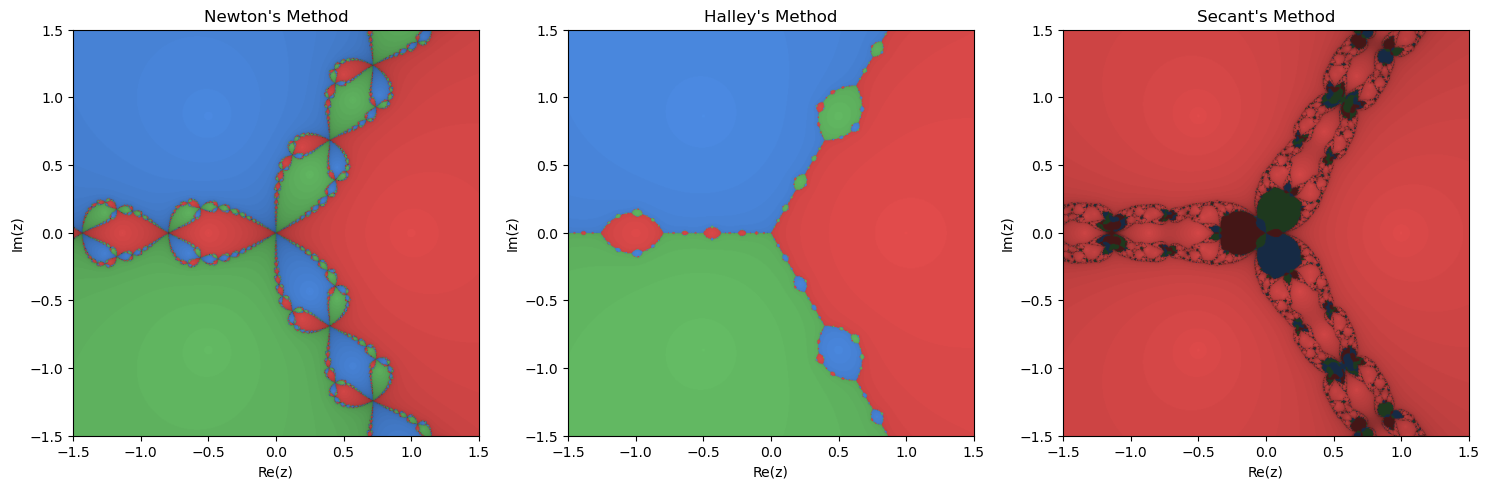

In [8]:
base_colors = np.array([
    [0.90, 0.30, 0.30],  # root 1
    [0.30, 0.55, 0.90],  # root e^(2*pi*i/3)
    [0.40, 0.75, 0.40],  # root e^(4*pi*i/3)
])

def render_basin(basin, escape_iter, max_iter=40):
    shade = 1.0 - 0.7 * (escape_iter / max_iter)
    img = base_colors[basin] * shade[..., None]
    return np.clip(img, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, (basin, escape_iter)) in zip(axes, results.items()):
    ax.imshow(render_basin(basin, escape_iter), extent=[-1.5, 1.5, -1.5, 1.5], origin="lower")
    ax.set_title(f"{name}'s Method")
    ax.set_xlabel("Re(z)")
    ax.set_ylabel("Im(z)")
plt.tight_layout()

Newton's basins meet at the origin in the classic three-way tangle, with the same self-similar pattern repeating at every zoom level along the boundary. Halley's basins are visibly *cleaner* — three large, simply-shaped regions with only small pockets of complexity near where they meet, since converging in fewer iterations leaves less room for a starting point to wander into a neighboring basin first.

The secant fractal looks strikingly different: the real root's basin (red) swallows almost the entire plane, apart from a scattered, chaotic tangle of small islands along the diagonals. That's a direct consequence of how we chose the second starting point — a small *real* offset, `eps`, from the first. That choice breaks the problem's three-fold symmetry, nudging ambiguous points toward whichever root that real-valued nudge happens to favor. It's a good reminder that the secant method's second starting point isn't a free parameter to ignore; it shapes the outcome as much as the first one does.

In all three, the boundary itself is never a smooth curve — it's fractal, and a starting point a fraction of a percent from its neighbor can converge to a different root entirely, or take far longer to get there. That's the flip side of these methods being fast: they're also locally chaotic near a basin boundary.

## Metrics
Convergence order tells us how fast the error shrinks *per iteration*, but it doesn't account for how much work each iteration costs. Let's put some numbers to both.

### Empirical order of convergence
Given three consecutive errors $e_{n-1}, e_n, e_{n+1}$, we can estimate the convergence order directly from the data, using $p \approx \dfrac{\ln(e_{n+1}/e_n)}{\ln(e_n/e_{n-1})}$, and compare it against the theoretical values derived above (2 for Newton, 3 for Halley, $\varphi \approx 1.618$ for secant).

In [9]:
def empirical_order(history, root):
    errors = np.abs(np.array(history) - root)
    errors = errors[errors > 1e-15]  # drop noise once we hit float precision
    return np.log(errors[2:] / errors[1:-1]) / np.log(errors[1:-1] / errors[:-2])

for name, hist in [("Newton", hist_n), ("Halley", hist_h), ("Secant", hist_s)]:
    orders = empirical_order(hist, true_root)
    print(f"{name:>7}: empirical order \u2248 {orders[-1]:.3f}")

 Newton: empirical order ≈ 2.000
 Halley: empirical order ≈ 3.135
 Secant: empirical order ≈ 1.667


### Efficiency index
Newton's method needs $f$ and $f'$ each iteration (2 evaluations), Halley's needs $f$, $f'$, and $f''$ (3 evaluations), and the secant method only needs one *new* evaluation of $f$ per iteration, since it reuses the previous point. The **efficiency index**, $\text{order}^{1/\text{evaluations}}$, captures convergence per unit of work rather than per iteration:

In [10]:
efficiency = {
    "Newton (order 2, 2 evals/iter)": 2 ** (1 / 2),
    "Halley (order 3, 3 evals/iter)": 3 ** (1 / 3),
    "Secant (order 1.618, 1 eval/iter)": 1.6180339887 ** (1 / 1),
}
for name, ei in efficiency.items():
    print(f"{name:<38} efficiency index = {ei:.3f}")

Newton (order 2, 2 evals/iter)         efficiency index = 1.414
Halley (order 3, 3 evals/iter)         efficiency index = 1.442
Secant (order 1.618, 1 eval/iter)      efficiency index = 1.618


Despite having the lowest convergence order, the secant method comes out ahead on efficiency: it does less work per step than Newton's method does, and that more than makes up for its slower per-iteration rate. Halley's method has the highest theoretical order, but the extra second-derivative evaluation eats into its efficiency advantage.

### Cost across the complex plane
We can also reuse the fractal grids computed above to measure the average number of iterations each method needed, across hundreds of thousands of starting points at once.

In [11]:
for name, (basin, escape_iter) in results.items():
    converged_mask = escape_iter < 40
    print(
        f"{name:>7}: converged on {converged_mask.mean():.1%} of starting points, "
        f"averaging {escape_iter[converged_mask].mean():.2f} iterations"
    )

 Newton: converged on 100.0% of starting points, averaging 5.73 iterations
 Halley: converged on 100.0% of starting points, averaging 2.77 iterations
 Secant: converged on 92.9% of starting points, averaging 7.84 iterations


Newton and Halley converge from every single starting point in the grid, with Halley needing roughly half as many iterations as Newton on average, right in line with its higher order. The secant method is the outlier: it only converges from about 93% of starting points. Its second "point" at each pixel is just a small offset from the first, so near a basin boundary that pair can behave erratically — sometimes overshooting into a different basin entirely, sometimes failing to converge within `max_iter`. It's a concrete example of the reliability cost that comes with not using a derivative.

## Conclusion
We built Newton's, Halley's, and the secant method from the same idea — approximate $f$ near the current guess, then jump to where the approximation crosses zero — with each method differing only in how it builds that approximation. Newton's method uses a tangent line, Halley's method adds curvature for a faster (but pricier) step, and the secant method trades the derivative for a second point, converging a bit slower per iteration but at a lower cost per step, which is why its efficiency index actually edges out Newton's.

The complex-plane visualizations are also a useful reminder that these are *local* methods: fast and reliable near a root, but sensitive to the starting guess near a basin boundary, where a tiny change in $x_0$ can send you to a different root entirely, or cause the method to diverge. In practice, that means pairing these methods with safeguards — bracketing, damping, or a fallback like bisection — rather than trusting a single guess blindly, especially when the shape of $f$ isn't already well understood.